## libs import

In [1]:
import sqlite3
import pandas as pd

## connection

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

## query for date from checker for users

In [3]:
query = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
df = pd.read_sql_query(query, connection)
df['date'] = pd.to_datetime(df['timestamp']).dt.date
df['time'] = pd.to_datetime(df['timestamp']).dt.time
df.drop('timestamp', axis=True, inplace=True)

In [5]:
df.head()

,date,time
0,2020-04-17,05:19:02.744528
1,2020-04-17,05:22:35.249331
2,2020-04-17,05:22:45.549397
3,2020-04-17,05:34:14.691200
4,2020-04-17,05:34:24.422370


## df preprocessing

In [6]:
bins = ['00:00:00', '04:00:00', '10:00:00', '17:00:00', '23:59:59']
labels = ['night', 'morning', 'afternoon', 'evening']

In [7]:
df["daytime"] = pd.cut(df['time'], bins=pd.to_datetime(bins, format = '%H:%M:%S').time, 
                           labels=labels, 
                           right=True)

In [8]:
daytime_df = df.groupby(['date', 'daytime'], observed=False).count()
daytime_df.reset_index(inplace=True)

## pivot table creating: counts of commits per day and daytime

In [9]:
daytime_pivot = daytime_df.pivot(index='date', columns='daytime', values='time')

In [10]:
daytime_pivot.head()

daytime,night,morning,afternoon,evening
date,,,,
2020-04-17,0,13,10,0
2020-04-18,0,1,33,35
2020-04-19,2,4,16,11
2020-04-20,0,0,12,13
2020-04-21,0,0,0,25


## Plot. Commits per day

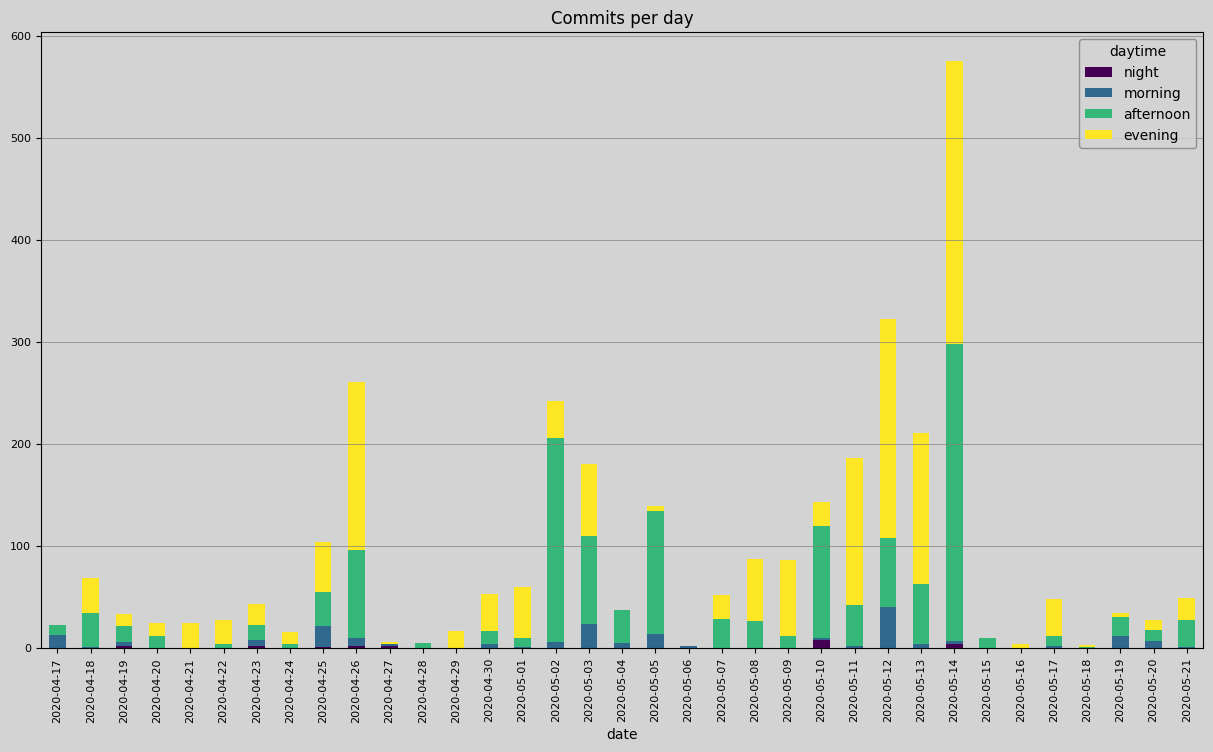

In [24]:
ax = daytime_pivot.reset_index().plot(x='date', y = ['night', 'morning', 'afternoon', 'evening'], kind='bar', stacked=True, colormap='viridis',
                                 figsize=(15, 8), fontsize=8, title="Commits per day")
ax.tick_params(axis='x', rotation=90)
ax.figure.set_facecolor('lightgray')
ax.set_facecolor('lightgray')
legend = ax.get_legend()
if legend:  # Проверяем, есть ли легенда
    legend.get_frame().set_facecolor('lightgray')  # Заливаем фон легенды серым
    legend.get_frame().set_edgecolor('gray')  # Устанавливаем цвет рамки легенды (опционально)
ax.grid(axis='y', color='gray', linestyle='-', linewidth=0.5)

## Answer for questions:

### “When do our users usually commit the labs: in the night, morning, afternoon, or evening?”
### The answer is the two most common periods: afternoon and evening.
### Which day has the most number of commits and at the same time, the number of commits in the evening is higher than in the afternoon? The answer is - 2020-05-12

## connection close

In [25]:
connection.close()